In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os

In [27]:
# # Load PCA data

X_train_pca = np.load('../data/processed/1X_train_pca.npy')
X_test_pca = np.load('../data/processed/1X_test_pca.npy')

In [28]:
print(f"Train shape: {X_train_pca.shape}")
print(f"Test shape: {X_test_pca.shape}")

Train shape: (1792, 8)
Test shape: (448, 8)


## **Determine Optimal Number of Clusters (Elbow Method)**

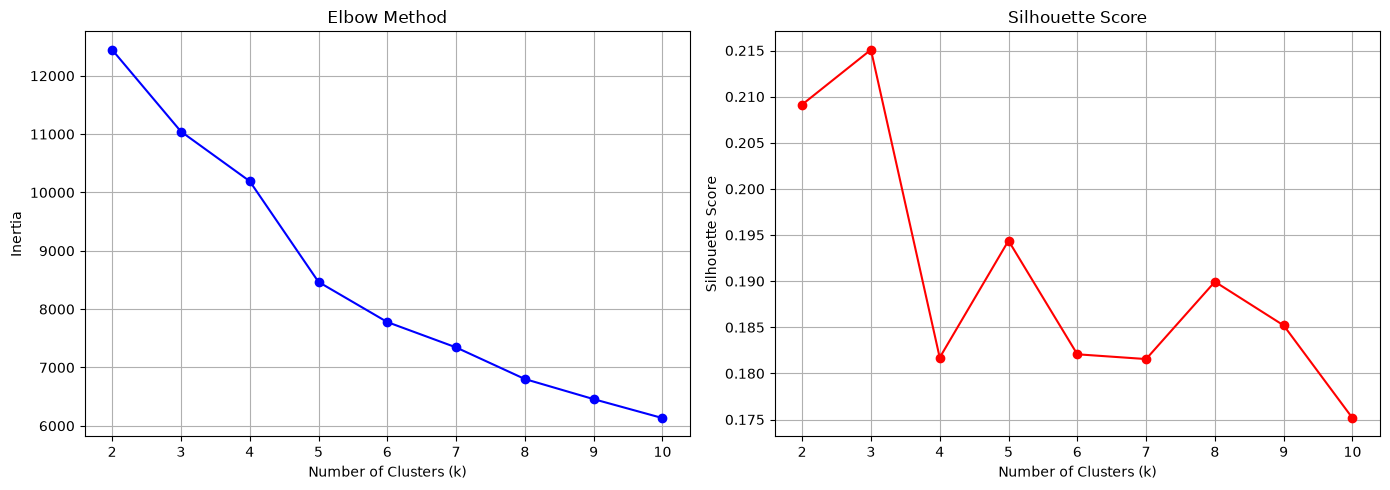

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Find optimal k using Elbow Method
inertias = [] 
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_pca)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_pca, kmeans.labels_))

    # Plot Elbow
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True)

ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [30]:
# Find optimal k
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_k}")
print(f"Best silhouette score: {max(silhouette_scores):.4f}")

Optimal number of clusters: 3
Best silhouette score: 0.2151


In [31]:
# Train final model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train_pca)
test_clusters = kmeans.predict(X_test_pca)

print(f"Train cluster distribution: {np.bincount(train_clusters)}")
print(f"Test cluster distribution: {np.bincount(test_clusters)}")

Train cluster distribution: [860 670 262]
Test cluster distribution: [201 180  67]


## **HIERARCHICAL CLUSTERING (Agglomerative)**

In [32]:
# HIERARCHICAL CLUSTERING (Agglomerative)
from sklearn.cluster import AgglomerativeClustering

# Different nubers of clusters
k_values =[2, 3, 4, 5]
linkage_types = ['ward', 'complete', 'average']

best_score = -1
best_params = None
bst_model = None
best_train_labels = None
best_test_labels = None

for linkage in linkage_types:
    for k in k_values:
        # for ward linkage, only works with euclidean distance
        if linkage == 'ward':
            agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    else:
        agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)


    # Fit on train
    train_lables = agg.fit_predict(X_train_pca)

    # Calculate silhouette
    score = silhouette_score(X_train_pca, train_lables)

    print(f"Linkage={linkage}, k={k}:  Silhouette={score:.4f}")

    # Track best
    if score > best_score:
        best_score = score
        best_params = f"{linkage}_k={k}"
        best_models = agg
        best_train_labels = train_lables

        # Predict test(Agglomerative can't transform, so fit on all data)
        agg_test = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        best_test_labels = agg_test.fit_predict(X_train_pca)


print(f"\nBest Agglomerative: {best_params} (Silhouette: {best_score:.4f})")        

Linkage=ward, k=5:  Silhouette=0.1805
Linkage=complete, k=5:  Silhouette=0.1490
Linkage=average, k=5:  Silhouette=0.2946

Best Agglomerative: average_k=5 (Silhouette: 0.2946)


## **GAUSSIAN MIXTURE MODEL (GMM)**

In [33]:
# GAUSSIAN MIXTURE MODEL (GMM)
from sklearn.mixture import GaussianMixture

# Try different parameters
k_values = [2, 3, 4, 5]
covariance_types = ['full', 'tied', 'diag', 'spherical']

best_score = -1
best_params = None
best_model = None
best_train_labels = None
best_test_labels = None

for cov_type in covariance_types:
    for k in k_values:
        gmm = GaussianMixture(n_components=k, covariance_type=cov_type, random_state=42)

        # Fit and predict on train
        train_lables = gmm.fit_predict(X_train_pca)

        # Calculate silhouette
        score = silhouette_score(X_train_pca, train_lables)

        print(f"Cov={cov_type}, k={k}: Silhouette={score:.4f}")


        # Track best
        if score > best_score:
            best_score = score
            best_params = f"{cov_type}_k={k}"
            best_model = gmm


            # Predict Test
            best_train_labels = train_lables
            best_test_labels = gmm.predict(X_test_pca)

print(f"\n Best GMM: {best_params} (Silhouette: {best_score:.4f})")

Cov=full, k=2: Silhouette=0.5998
Cov=full, k=3: Silhouette=0.2623
Cov=full, k=4: Silhouette=0.1915
Cov=full, k=5: Silhouette=0.1435
Cov=tied, k=2: Silhouette=0.1876
Cov=tied, k=3: Silhouette=0.1168
Cov=tied, k=4: Silhouette=0.1533
Cov=tied, k=5: Silhouette=0.1432
Cov=diag, k=2: Silhouette=0.6077
Cov=diag, k=3: Silhouette=0.1633
Cov=diag, k=4: Silhouette=0.2135
Cov=diag, k=5: Silhouette=0.1656
Cov=spherical, k=2: Silhouette=0.2093
Cov=spherical, k=3: Silhouette=0.1930
Cov=spherical, k=4: Silhouette=0.1471
Cov=spherical, k=5: Silhouette=0.1395

 Best GMM: diag_k=2 (Silhouette: 0.6077)


## **DBSCAN (Density-Based)**

In [34]:
# DBSCAN CLUSTERING
from sklearn.cluster import DBSCAN

# Try different parameters
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
min_samples_values = [2, 3, 4, 5]

best_score = -1
best_params = None
best_model = None
best_train_labels_dbscan = None
best_test_labels_dbscan = None

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)


        # Fit and predict on train
        train_lables_dbscan = dbscan.fit_predict(X_train_pca)

        # Count clusters (excluding noise -1)
        n_clusters = len(set(train_lables_dbscan)) - (1 if -1 in train_lables_dbscan else 0)

        n_noise = list(train_lables_dbscan).count(-1)
        noise_pct = (n_noise / len(train_lables_dbscan))*100

        # Calculate silhouette (only on non-noise points)
        if n_clusters >= 2:
            # Filter out noise points
            mask = train_lables_dbscan != -1
            score = silhouette_score(X_train_pca[mask], train_lables_dbscan[mask])
            print(f"eps={eps}, min_samples={min_samples}: Clusters={n_clusters}, "f"Noise={noise_pct:.1f}%, Silhouette={score:.4f}")


            # Track best
            if score > best_score:
                best_score = score
                best_params = f"eps={eps}_min_samples={min_samples}"
                best_model = dbscan
                best_train_labels_dbscan = train_lables_dbscan

                # Predict test
                best_test_labels_dbscan = dbscan.fit_predict(X_test_pca)
            else:
                print(f"eps={eps}, min_samples={min_samples}: Only {n_clusters} cluster(s) found")

print(f"\nBest DBSCAN: {best_params} (Silhouette: {best_score:.4f})")                

eps=0.5, min_samples=2: Clusters=196, Noise=74.7%, Silhouette=0.7593
eps=0.5, min_samples=3: Clusters=44, Noise=91.6%, Silhouette=0.6817
eps=0.5, min_samples=3: Only 44 cluster(s) found
eps=0.5, min_samples=4: Clusters=10, Noise=97.5%, Silhouette=0.7676
eps=0.5, min_samples=5: Clusters=3, Noise=99.1%, Silhouette=0.8448
eps=1.0, min_samples=2: Clusters=85, Noise=11.5%, Silhouette=-0.2994
eps=1.0, min_samples=2: Only 85 cluster(s) found
eps=1.0, min_samples=3: Clusters=30, Noise=17.6%, Silhouette=-0.2240
eps=1.0, min_samples=3: Only 30 cluster(s) found
eps=1.0, min_samples=4: Clusters=16, Noise=22.4%, Silhouette=-0.1651
eps=1.0, min_samples=4: Only 16 cluster(s) found
eps=1.0, min_samples=5: Clusters=14, Noise=26.6%, Silhouette=-0.1362
eps=1.0, min_samples=5: Only 14 cluster(s) found
eps=1.5, min_samples=2: Clusters=7, Noise=2.2%, Silhouette=0.1303
eps=1.5, min_samples=2: Only 7 cluster(s) found
eps=1.5, min_samples=3: Clusters=4, Noise=2.5%, Silhouette=0.2143
eps=1.5, min_samples=3: Onl

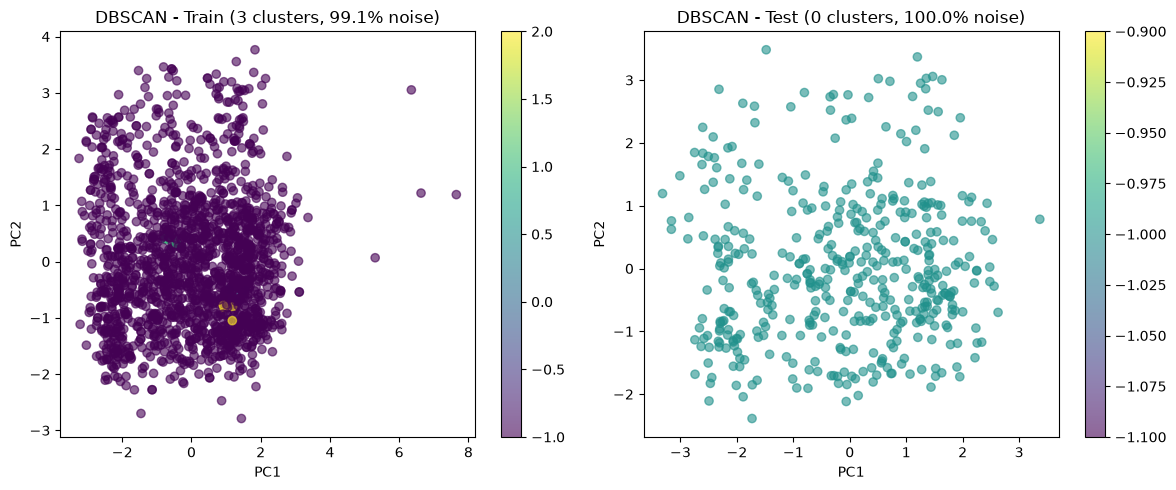

In [35]:
# PLOT DBSCAN RESULTS
plt.figure(figsize=(12, 5))

# Train clusters
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=best_train_labels_dbscan, cmap='viridis', alpha=0.6)
plt.colorbar(scatter)
n_clusters_final = len(set(best_train_labels_dbscan)) - (1 if -1 in best_train_labels_dbscan else 0)
n_noise_final = list(best_train_labels_dbscan).count(-1)
noise_pct_final = (n_noise_final / len(best_train_labels_dbscan)) * 100
plt.title(f'DBSCAN - Train ({n_clusters_final} clusters, {noise_pct_final:.1f}% noise)')
plt.xlabel('PC1')
plt.ylabel('PC2')


# Test clusters
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], 
                      c=best_test_labels_dbscan, cmap='viridis', alpha=0.6)
plt.colorbar(scatter)
n_clusters_test = len(set(best_test_labels_dbscan)) - (1 if -1 in best_test_labels_dbscan else 0)
n_noise_test = list(best_test_labels_dbscan).count(-1)
noise_pct_test = (n_noise_test / len(best_test_labels_dbscan)) * 100
plt.title(f'DBSCAN - Test ({n_clusters_test} clusters, {noise_pct_test:.1f}% noise)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.tight_layout()
plt.show()

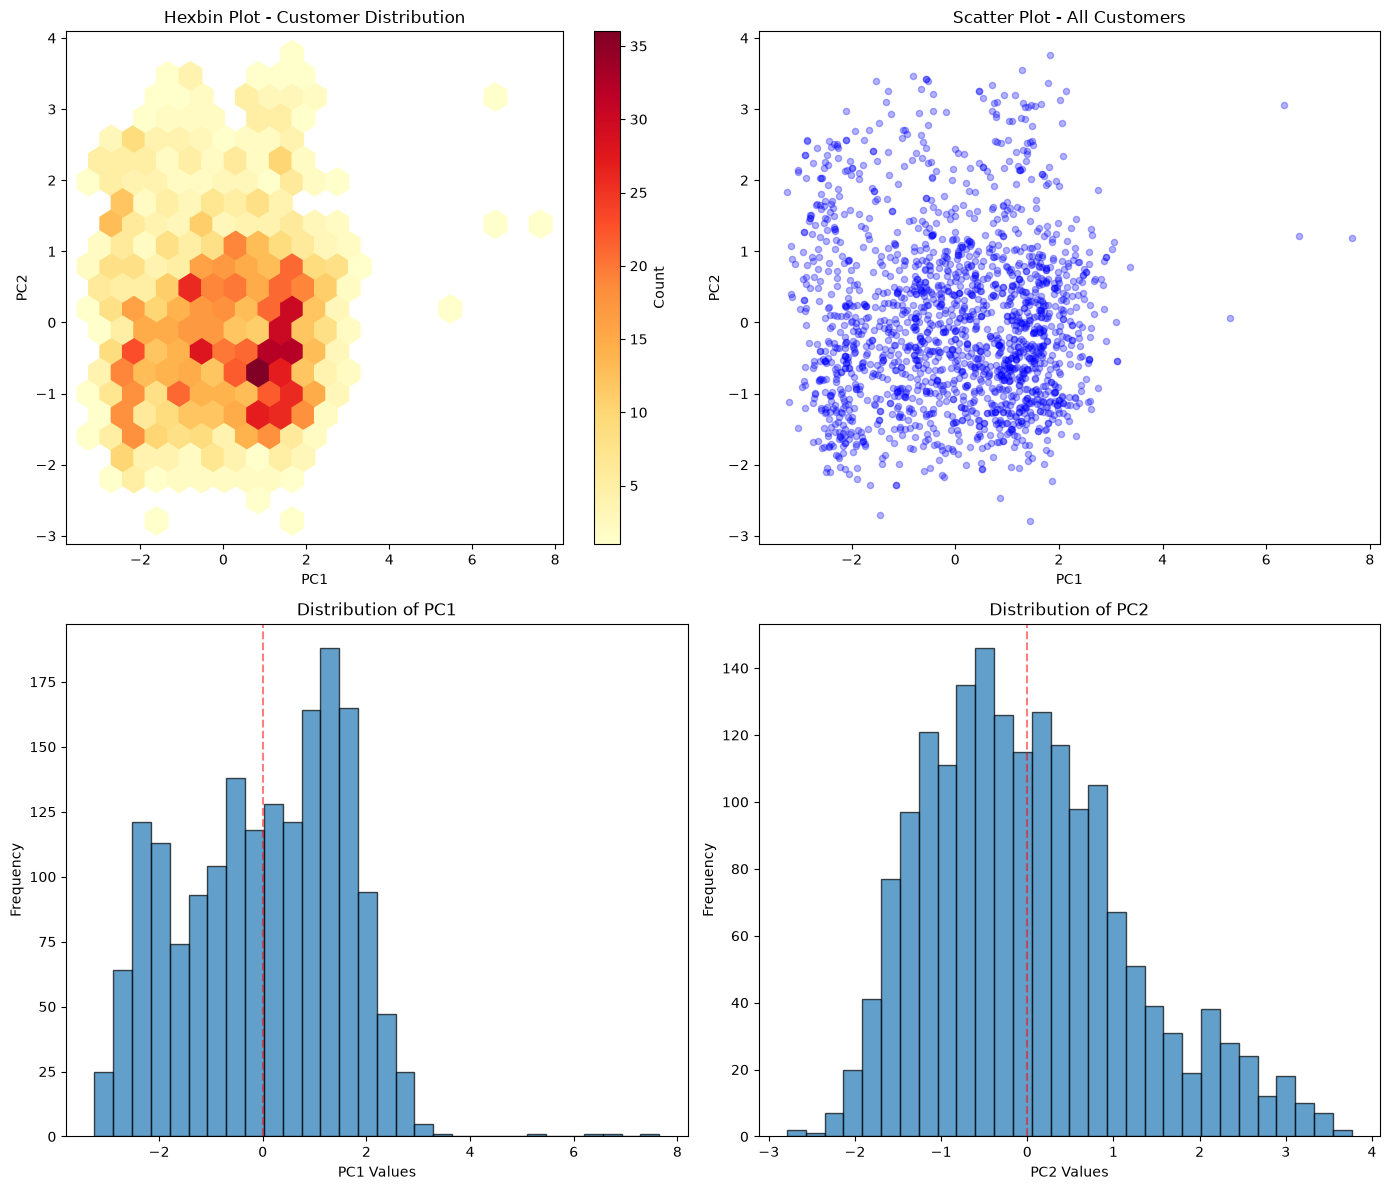

In [36]:
# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Hexbin plot (2D histogram)
hexbin = axes[0, 0].hexbin(X_train_pca[:, 0], X_train_pca[:, 1], 
                            gridsize=20, cmap='YlOrRd', mincnt=1)
axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')
axes[0, 0].set_title('Hexbin Plot - Customer Distribution')
plt.colorbar(hexbin, ax=axes[0, 0], label='Count')

# 2. Scatter plot with transparency
axes[0, 1].scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                   alpha=0.3, s=20, c='blue')
axes[0, 1].set_xlabel('PC1')
axes[0, 1].set_ylabel('PC2')
axes[0, 1].set_title('Scatter Plot - All Customers')

# 3. Histogram of PC1
axes[1, 0].hist(X_train_pca[:, 0], bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('PC1 Values')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of PC1')
axes[1, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# 4. Histogram of PC2
axes[1, 1].hist(X_train_pca[:, 1], bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('PC2 Values')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of PC2')
axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [37]:
# Save best model

np.save('../data/processed/train_labels_dbscan_final.npy', best_train_labels_dbscan)
np.save('../data/processed/test_labels_dbscan_final.npy', best_test_labels_dbscan)